In [1]:
import simpy
import random
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
from gurobipy import Model, GRB, quicksum
import seaborn as sns

In [2]:
class CLASS:

    def __init__(self, service_rate, dropout_rate, dropout_cost, anandonment_rate_without_AI,
                anandonment_cost_without_AI, if_use_AI_or_not, supervision_cost,
                negative_anandonment_rate, positive_anandonment_rate,
                negative_anandonment_cost, holding_cost_without_AI, holding_cost_with_AI, benefit, arrival_rate,name,
                fixed_overhead_cost):
        
        self.service_rate = service_rate
        self.dropout_rate = dropout_rate
        self.dropout_cost = dropout_cost
        self.anandonment_rate_without_AI = anandonment_rate_without_AI
        self.anandonment_cost_without_AI = anandonment_cost_without_AI
        self.if_use_AI_or_not = if_use_AI_or_not
        self.supervision_cost = supervision_cost
        self.negative_anandonment_rate = negative_anandonment_rate
        self.positive_anandonment_rate = positive_anandonment_rate
        self.negative_anandonment_cost = negative_anandonment_cost
        self.holding_cost_without_AI = holding_cost_without_AI
        self.holding_cost_with_AI = holding_cost_with_AI
        self.benefit = benefit
        self.arrival_rate = arrival_rate
        self.fixed_overhead_cost = fixed_overhead_cost 
        self.name = name
        
        r = benefit * service_rate - dropout_rate * dropout_cost
        c = holding_cost_without_AI + anandonment_rate_without_AI * anandonment_cost_without_AI
        theta_w = negative_anandonment_rate + positive_anandonment_rate
        c_w = holding_cost_with_AI + negative_anandonment_cost * negative_anandonment_rate + supervision_cost - positive_anandonment_rate * benefit
        
        P = (r * anandonment_rate_without_AI + c * (service_rate + dropout_rate)) / anandonment_rate_without_AI
        P_w = (r * theta_w + c_w * (service_rate + dropout_rate)) / theta_w

        self.r = r
        self.c = c
        self.c_w = c_w
        self.P = P
        self.P_w = P_w

        self.z_upper = arrival_rate / (service_rate + dropout_rate)

        self.in_system = 0
        self.in_service = 0

    @property
    def index(self):

        return self.P * (1 - self.if_use_AI_or_not) + self.P_w * self.if_use_AI_or_not

In [3]:
def solve_ai_waitlist_milp(classes, N, fix_ai_choice=False, verbose=True, c_k=10):

    m = Model("AI_waitlist_MILP")

    if not verbose:
        m.Params.OutputFlag = 0

    I = range(len(classes))

    z = m.addVars(I, lb=0.0, name="z")              
    w = m.addVars(I, vtype=GRB.BINARY, name="w")    
    y = m.addVars(I, lb=0.0, name="y")            
    K = m.addVar(lb=0.0, name="K")
    
    params = {}
    for i, cls in enumerate(classes):
        mu = cls.service_rate
        gamma = cls.dropout_rate
        lam = cls.arrival_rate

        b = cls.benefit
        h = cls.holding_cost_without_AI
        h_w = cls.holding_cost_with_AI

        theta_n = cls.anandonment_rate_without_AI
        alpha_n = cls.anandonment_cost_without_AI

        theta_wp = cls.positive_anandonment_rate
        theta_wn = cls.negative_anandonment_rate
        alpha_wn = cls.negative_anandonment_cost

        a = cls.supervision_cost
        f_bar = cls.fixed_overhead_cost

        r = b * mu - cls.dropout_cost * gamma
        c = h + alpha_n * theta_n
        theta_w = theta_wp + theta_wn
        c_w = h_w + alpha_wn * theta_wn + a - theta_wp * b

        # P, P^w
        P = (r * theta_n + c * (mu + gamma)) / theta_n
        P_w = (r * theta_w + c_w * (mu + gamma)) / theta_w

        z_max = lam / (mu + gamma)

        A = c / theta_n
        B = c_w / theta_w

        params[i] = dict(
            mu=mu, gamma=gamma, lam=lam,
            r=r, c=c, c_w=c_w,
            theta_n=theta_n, theta_w=theta_w,
            P=P, P_w=P_w,
            z_max=z_max,
            A=A, B=B,
            f_bar=f_bar,
        )

    for i in I:
        m.addConstr(z[i] <= params[i]["z_max"], name=f"stab[{i}]")

    m.addConstr(quicksum(z[i] for i in I) <= N + K, name="capacity")

    for i in I:
        z_max = params[i]["z_max"]
        m.addConstr(y[i] <= z[i], name=f"mc1[{i}]")
        m.addConstr(y[i] <= z_max * w[i], name=f"mc2[{i}]")
        m.addConstr(y[i] >= z[i] - z_max * (1 - w[i]), name=f"mc3[{i}]")

    if fix_ai_choice:
        for i, cls in enumerate(classes):
            if cls.if_use_AI_or_not in (0, 1):
                m.addConstr(w[i] == int(cls.if_use_AI_or_not),
                            name=f"fix_w[{i}]")

    obj = 0
    for i in I:
        P = params[i]["P"]
        P_w = params[i]["P_w"]
        lam = params[i]["lam"]
        A = params[i]["A"]
        B = params[i]["B"]
        f_bar = params[i]["f_bar"]

        obj += P * z[i]
        obj += (P_w - P) * y[i]
        obj += -lam * (A + (B - A) * w[i])
        obj += -f_bar * w[i]

    m.setObjective(obj - c_k *K, GRB.MAXIMIZE)

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        if verbose:
            print(f"\nOptimal objective value: {m.ObjVal:.6f}\n")
            for i, cls in enumerate(classes):
                print(f"Class {getattr(cls, 'name', i)}:")
                print(f"  z[{i}] = {z[i].X:.6f}")
                print(f"  w[{i}] = {int(round(w[i].X))}  (1=use AI, 0=no AI)")
                print(f"  y[{i}] = {y[i].X:.6f}")
                print(f"  K = {K.X:.6f}")
        result = {
            "obj": m.ObjVal,
            "z": {i: z[i].X for i in I},
            "w": {i: int(round(w[i].X)) for i in I},
            "y": {i: y[i].X for i in I},
            "K": K.X,
        }
        return result
    else:
        print("Model did not solve to optimality. Status:", m.Status)
        return None

In [4]:
beta = 0.82                 # show-up probability
dropout_rate = 0.0067       # gamma per week
abandonment_rate_wo_ai = 0.04  # theta^n per week
positive_abandonment_rate = 0.06   # theta^{w,p} per week
negative_abandonment_rate = 0.0005 # theta^{w,n} per week
supervision_cost = 1        # a_i per patient per week
fixed_overhead_cost = 640   # fbar_i per class per week

# Benefits (b_i)
b_MDD = 12000
b_AD  = 9000

# Costs derived from benefit
abandonment_cost_wo_ai_MDD = 0.02 * b_MDD   # alpha^n
abandonment_cost_wo_ai_AD  = 0.02 * b_AD

negative_abandonment_cost_MDD = 0.01 * b_MDD  # alpha^{w,n}
negative_abandonment_cost_AD  = 0.01 * b_AD

dropout_cost_MDD = 0.01 * b_MDD  # h^d
dropout_cost_AD  = 0.01 * b_AD

# Holding costs (weekly)
holding_cost_wo_ai_MDD = 324
holding_cost_wo_ai_AD  = 196

holding_cost_w_ai_MDD = 32.4
holding_cost_w_ai_AD  = 19.6

# Service rates: mu = beta * mu^b
mu_b_MDD = 2.96
mu_b_AD  = 2.96

service_rate_MDD  = beta * mu_b_MDD   # 2.4272
service_rate_AD   = beta * mu_b_AD    # 2.4272

# Arrival rates (weekly)
arrival_rate_MDD  = 81/30
arrival_rate_AD   = 57/20

In [5]:
df1 = pd.DataFrame()
df2 = pd.DataFrame()
df3 = pd.DataFrame()
df4 = pd.DataFrame()
df5 = pd.DataFrame()

for i in [10]:
    CLASS_A = CLASS(
        service_rate=(service_rate_MDD),
        dropout_rate=(dropout_rate),
        dropout_cost=(dropout_cost_MDD),
        anandonment_rate_without_AI=(abandonment_rate_wo_ai),
        anandonment_cost_without_AI=(abandonment_cost_wo_ai_MDD),
        if_use_AI_or_not=0,
        supervision_cost=(supervision_cost),
        negative_anandonment_rate=(negative_abandonment_rate),
        positive_anandonment_rate=(positive_abandonment_rate),
        negative_anandonment_cost=(negative_abandonment_cost_MDD),
        holding_cost_without_AI=(holding_cost_wo_ai_MDD),
        holding_cost_with_AI=(holding_cost_w_ai_MDD),
        benefit=(b_MDD)/4,
        arrival_rate=(arrival_rate_MDD) * i,
        fixed_overhead_cost=(fixed_overhead_cost),
        name="MDD"
    )
    
    CLASS_B = CLASS(
        service_rate=(service_rate_AD),
        dropout_rate=(dropout_rate),
        dropout_cost=(dropout_cost_AD),
        anandonment_rate_without_AI=(abandonment_rate_wo_ai),
        anandonment_cost_without_AI=(abandonment_cost_wo_ai_AD),
        if_use_AI_or_not=1,
        supervision_cost=(supervision_cost),
        negative_anandonment_rate=(negative_abandonment_rate),
        positive_anandonment_rate=(positive_abandonment_rate),
        negative_anandonment_cost=(negative_abandonment_cost_AD),
        holding_cost_without_AI=(holding_cost_wo_ai_AD),
        holding_cost_with_AI=(holding_cost_w_ai_AD),
        benefit=(b_AD),
        arrival_rate=(arrival_rate_AD) * i,
        fixed_overhead_cost=(fixed_overhead_cost),
        name="AD"
    )

   
    N = i

    info_wA = []
    info_wB = []
    info_K = []
    info_zA = []
    info_zB = []

    for c_k in tqdm(list(np.linspace(500,3000,1000))):
        result = solve_ai_waitlist_milp(
            classes=[CLASS_A, CLASS_B],
            N=N,
            fix_ai_choice=False,  
            verbose=False, c_k = c_k
        )
        info_wA.append(result["w"][0])
        info_wB.append(result["w"][1])
        info_K.append(result["K"])
        info_zA.append(result["z"][0])
        info_zB.append(result["z"][1])
        CLASS_A.if_use_AI_or_not = result["w"][0]
        CLASS_B.if_use_AI_or_not = result["w"][1]
        print(
    f"{N:3d} | c_k={c_k:6.3f} | wA={result['w'][0]:5.3f} | wB={result['w'][1]:5.3f} | "
    f"indexA={CLASS_A.index:7.3f} | indexB={CLASS_B.index:7.3f} | K={result["K"]:7.3f} | zA={result["z"][0]:7.3f}  | zB={result["z"][1]:7.3f}   " 
)


    df1[str(N)] = info_wA
    df2[str(N)] = info_wB
    df3[str(N)] = info_K
    df4[str(N)] = info_zA
    df5[str(N)] = info_zB

  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-08


 14%|██████████▉                                                                   | 141/1000 [00:00<00:01, 735.23it/s]

 10 | c_k=500.000 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=502.503 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=505.005 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=507.508 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=510.010 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=512.513 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=515.015 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=517.518 | wA=0.000 | wB=0.000 | indexA=27579.522 | indexB=34208.409 | K= 12.803 | zA= 11.093  | zB= 11.710   
 10 | c_k=520.020 | wA=0.000 | wB=0.000 

 22%|████████████████▉                                                             | 217/1000 [00:00<00:01, 740.58it/s]

...

 10 | c_k=2734.735 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2737.237 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2739.740 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2742.242 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2744.745 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2747.247 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2749.750 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2752.252 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2754.755 | wA=1.000 | wB=1.000 | indexA=1385.5

 95%|██████████████████████████████████████████████████████████████████████████▎   | 953/1000 [00:02<00:00, 412.74it/s]

 10 | c_k=2857.357 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2859.860 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2862.362 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2864.865 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2867.367 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2869.870 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2872.372 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2874.875 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2877.377 | wA=1.000 | wB=1.000 | indexA=1385.5

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 461.74it/s]

 10 | c_k=2947.447 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2949.950 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2952.452 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2954.955 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2957.457 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2959.960 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2962.462 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2964.965 | wA=1.000 | wB=1.000 | indexA=1385.528 | indexB=950.674 | K=  0.000 | zA= 10.000  | zB=  0.000   
 10 | c_k=2967.467 | wA=1.000 | wB=1.000 | indexA=1385.5

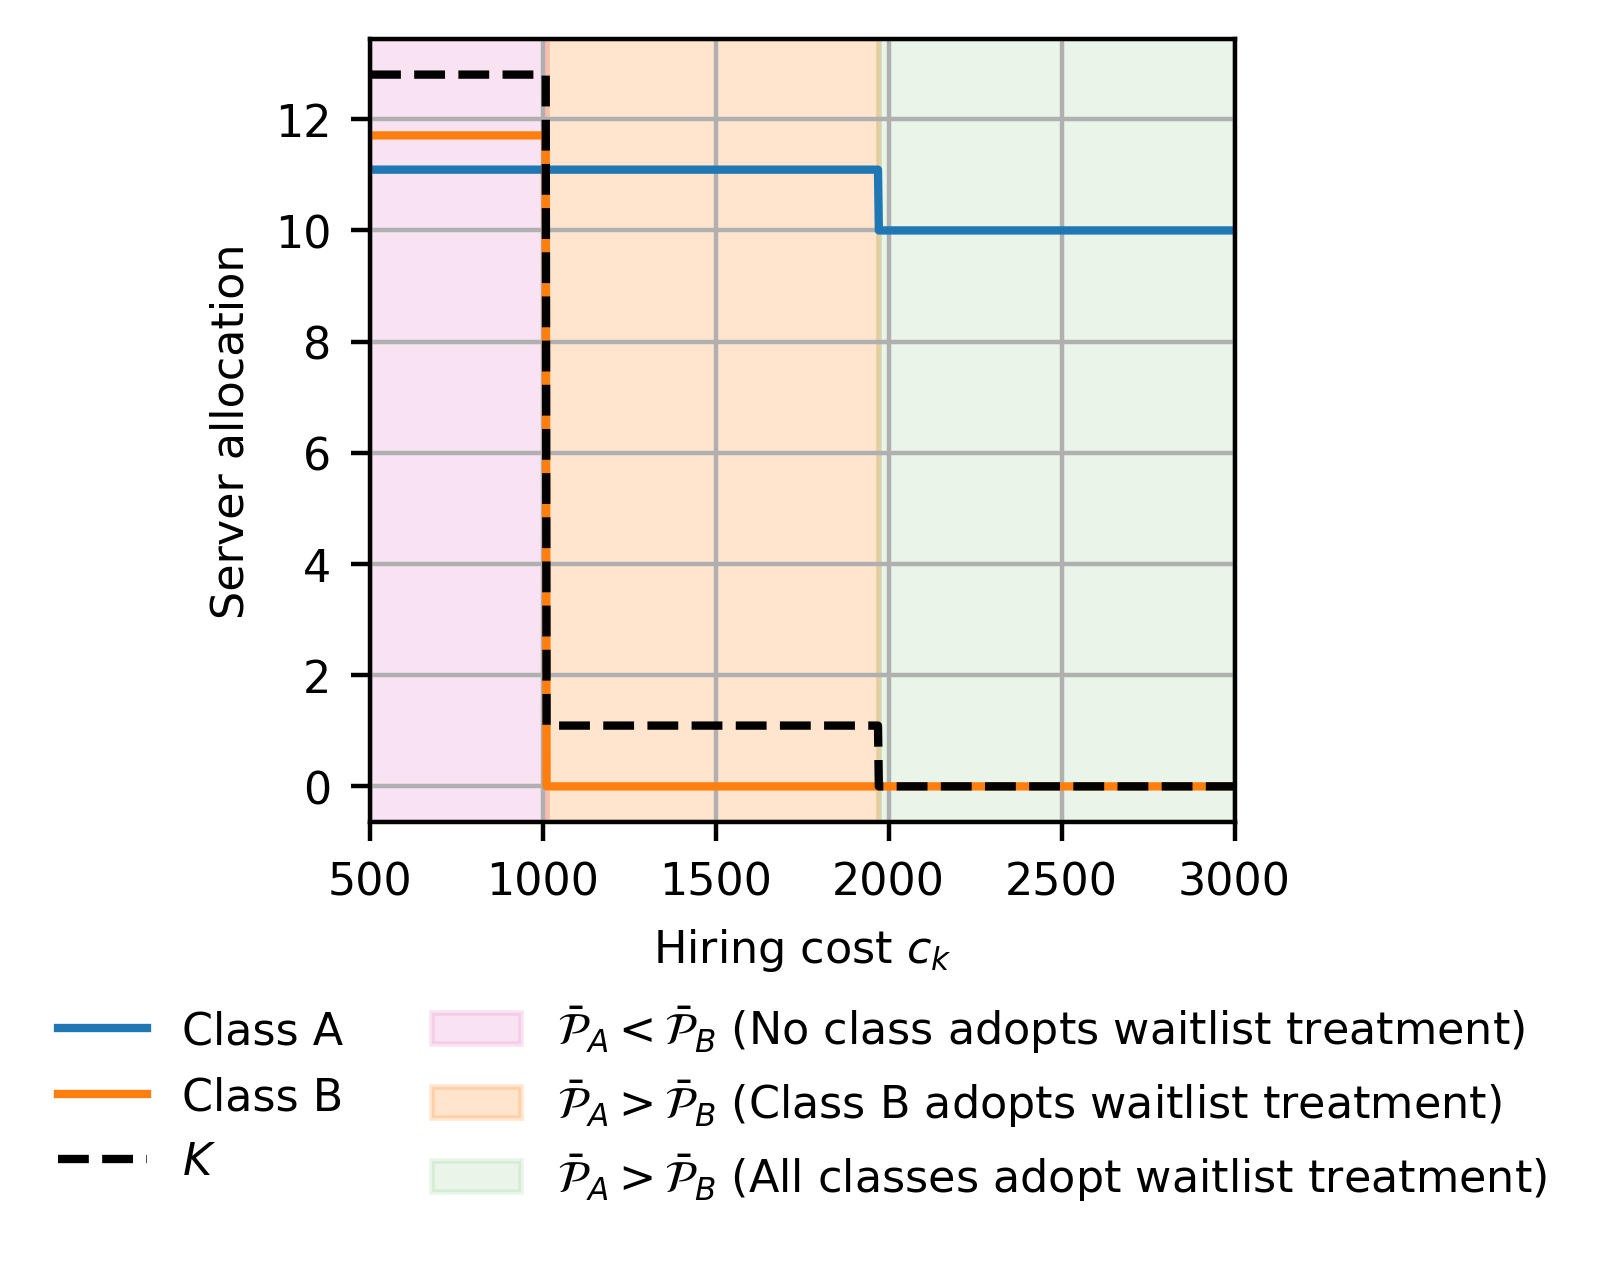

In [6]:
plt.rc('font', size=8, weight='normal')
plt.figure(figsize=(3.5, 3.3), dpi=400)

plt.plot(np.linspace(500,3000,500*2), info_zA, c='tab:blue', label=r'Class A',linestyle='-')
plt.plot(np.linspace(500,3000,500*2), info_zB, c='tab:orange', label=r'Class B',linestyle='-')
plt.plot(np.linspace(500,3000,500*2), info_K, c='black', label=r'$K$',linestyle='--')
plt.xlim(500,3000)
plt.grid()
plt.axvspan(500, 1010.511, color='tab:pink', alpha=0.2, label=r'$\bar{\mathcal{P}}_A<\bar{\mathcal{P}}_B$ (No class adopts waitlist treatment)')
plt.axvspan(1010.511, 1971.471, color='tab:orange', alpha=0.2, label=r'$\bar{\mathcal{P}}_A>\bar{\mathcal{P}}_B$ (Class B adopts waitlist treatment)')
plt.axvspan(1971.471, 3000, color='tab:green', alpha=0.1, label=r'$\bar{\mathcal{P}}_A>\bar{\mathcal{P}}_B$ (All classes adopt waitlist treatment)')
plt.xlabel(r"Hiring cost $c_k$")
plt.ylabel("Server allocation")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,framealpha=0)


plt.tight_layout()
plt.savefig('NE-3.pdf', dpi=500, bbox_inches='tight')
plt.show()